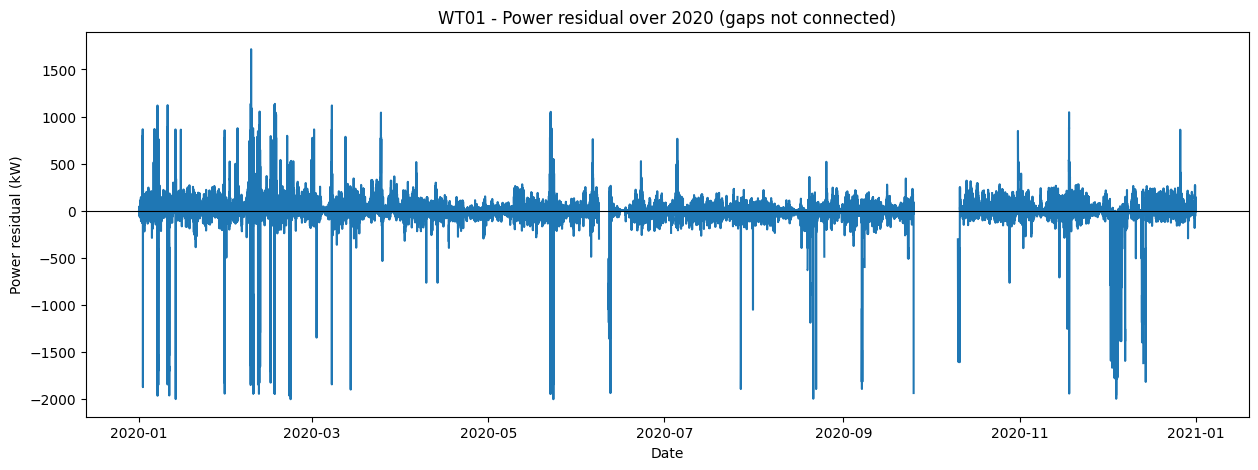

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("../src/etl")
from db_connection import engine

df = pd.read_sql("SELECT * FROM features", engine)
df.shape

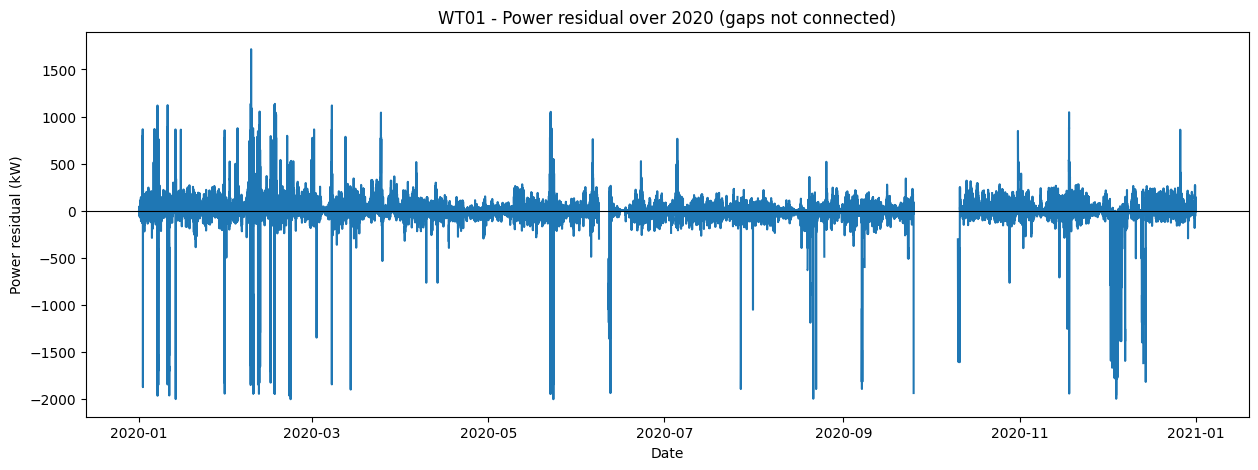

In [14]:
gap = wt01["ts"].diff() > pd.Timedelta(minutes=10)  # flags rows with a gap > 10 min between readings
wt01_clean = wt01.mask(gap)  # sets those rows to NaN so matplotlib doesn't draw a straight line across the gap

plt.figure(figsize=(15, 5))
plt.plot(wt01_clean["ts"], wt01_clean["power_residual"])
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Date")
plt.ylabel("Power residual (kW)")
plt.title("WT01 - Power residual over 2020 (gaps not connected)")
plt.show()


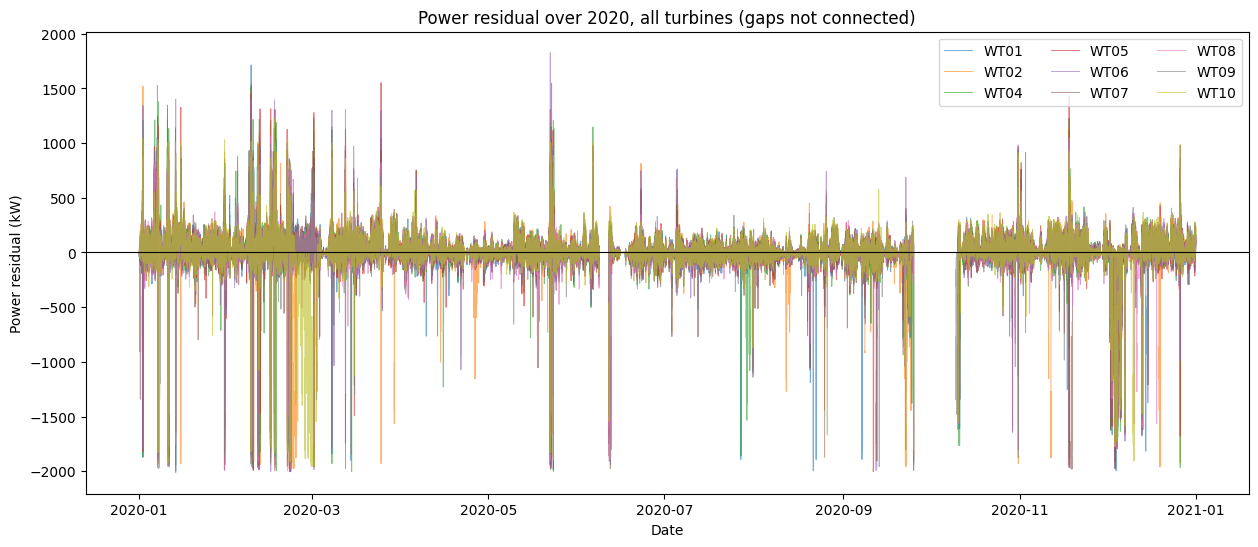

In [15]:
plt.figure(figsize=(15, 6))

colors = plt.cm.tab10.colors  # 10 distinct colors, one per turbine

for i, turbine_id in enumerate(sorted(df["turbine_id"].unique())):
    turbine_df = df[df["turbine_id"] == turbine_id].sort_values("ts")

    gap = turbine_df["ts"].diff() > pd.Timedelta(minutes=10)  # same gap criterion as WT01
    turbine_df_clean = turbine_df.mask(gap)  # avoids the artificial straight line in the combined plot

    plt.plot(
        turbine_df_clean["ts"],
        turbine_df_clean["power_residual"],
        label=turbine_id,
        color=colors[i % len(colors)],
        alpha=0.6,
        linewidth=0.7,
    )

plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Date")
plt.ylabel("Power residual (kW)")
plt.title("Power residual over 2020, all turbines (gaps not connected)")
plt.legend(loc="upper right", ncol=3)
plt.show()